In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

print(path)

100%|██████████| 21.8M/21.8M [00:01<00:00, 19.7MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1


--- ANALISI ESPLORATIVA: DIMENSIONI E CAMPIONI ORIGINALI ---
Classe: cloudy       | File: train_9108.jpg       | Dimensione originale: 256x256 pixel | Canali: CMYK
Classe: desert       | File: desert(1009) (1).jpg | Dimensione originale: 256x256 pixel | Canali: RGB
Classe: green_area   | File: Forest_2805.jpg      | Dimensione originale: 64x64 pixel | Canali: RGB
Classe: water        | File: SeaLake_1940.jpg     | Dimensione originale: 64x64 pixel | Canali: RGB


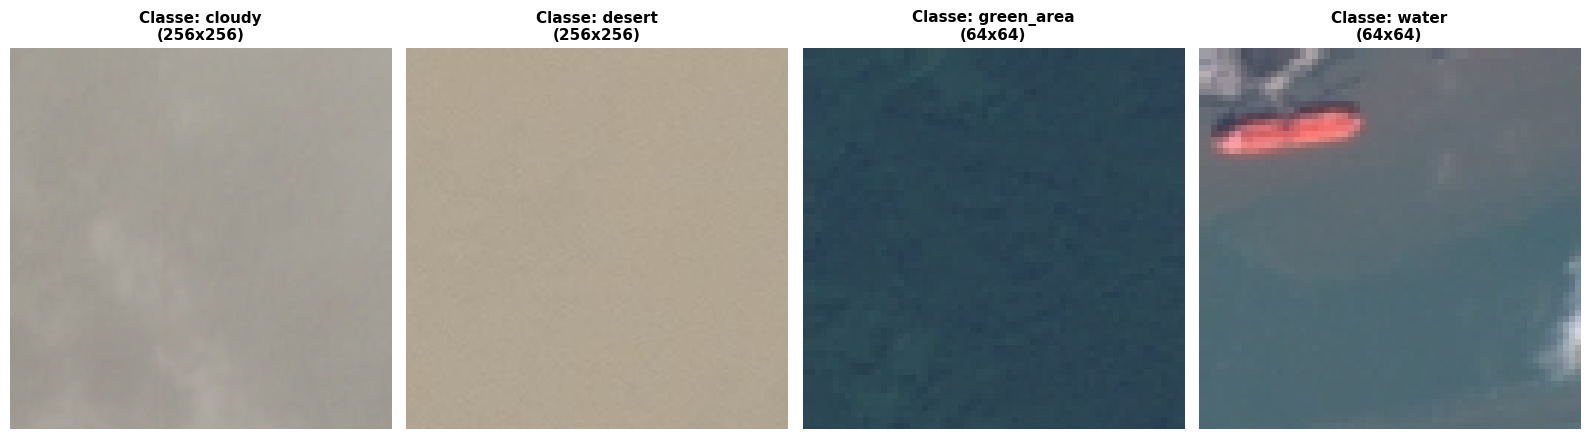



--- CONTEGGIO TOTALE IMMAGINI PER CLASSE ---
 - cloudy      : 1500 immagini totali
 - desert      : 1131 immagini totali
 - green_area  : 1500 immagini totali
 - water       : 1500 immagini totali


In [ ]:
import os
import pathlib
import matplotlib.pyplot as plt
from PIL import Image

# 1. Configurazione e controllo dei percorsi dei dati
data_dir = pathlib.Path(f"{path}/data")
if not data_dir.exists():
    data_dir = pathlib.Path('./satellite_dataset')

# Otteniamo la lista delle cartelle (classi) escludendo eventuali file nascosti
class_names = sorted([f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))])

print("--- ANALISI ESPLORATIVA: DIMENSIONI E CAMPIONI ORIGINALI ---")

# Prepariamo la griglia grafica (1 riga, 4 colonne)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)

    # Recuperiamo la lista di tutte le immagini nella cartella della classe
    all_images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if len(all_images) == 0:
        print(f"Attenzione: La cartella {class_name} sembra vuota!")
        continue

    # Scegliamo la prima immagine disponibile per la visualizzazione
    sample_img_name = all_images[0]
    sample_img_path = os.path.join(class_path, sample_img_name)

    # Carichiamo l'immagine usando PIL (evita conversioni strane o problemi di canali)
    with Image.open(sample_img_path) as img:
        width, height = img.size
        mode = img.mode # es. RGB

        print(f"Classe: {class_name.ljust(12)} | File: {sample_img_name.ljust(20)} | Dimensione originale: {width}x{height} pixel | Canali: {mode}")

        # Mostriamo l'immagine nella sotto-griglia corrispondente
        axes[i].imshow(img)
        axes[i].set_title(f"Classe: {class_name}\n({width}x{height})", fontsize=11, fontweight='bold')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70 + "\n")

# Conteggio totale dei file per verificare il bilanciamento del dataset
print("--- CONTEGGIO TOTALE IMMAGINI PER CLASSE ---")
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    total_files = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f" - {class_name.ljust(12)}: {total_files} immagini totali")

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

# Iperparametri di input
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42

print("Generazione dei Dataset di Addestramento e Validazione...")
# Dataset di Train (80% dei dati totali)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'  # Genera etichette in formato One-Hot Vector
)

# Dataset di validazione iniziale (20% dei dati totali)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Dividiamo il val_ds a metà per ricavare Validation Set e Test Set (10% e 10%)
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print(f"Classi individuate: {train_ds.class_names}")

# Strato sequenziale per l'invarianza spaziale (Data Augmentation)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.1)
])

# Funzioni di mappatura per la pipeline tf.data
def prepare_train_pipeline(x, y):
    x = data_augmentation(x, training=True) # Applica le trasformazioni casuali
    x = preprocess_input(x)                 # Applica lo scaling nativo di ResNet
    return x, y

def prepare_val_test_pipeline(x, y):
    x = preprocess_input(x)                 # Solo lo scaling senza alterazioni geometriche
    return x, y

# Ottimizzazione dei flussi di memoria tramite Prefetch e Autotune
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(prepare_train_pipeline, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(prepare_val_test_pipeline, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(prepare_val_test_pipeline, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

print("Pipeline tf.data configurata con successo.")

Generazione dei Dataset di Addestramento e Validazione...
Found 5631 files belonging to 4 classes.
Using 4505 files for training.
Found 5631 files belonging to 4 classes.
Using 1126 files for validation.
Classi individuate: ['cloudy', 'desert', 'green_area', 'water']
Pipeline tf.data configurata con successo.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Caricamento di ResNet50 senza i livelli densi finali di ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelamento dei pesi pre-addestrati del backbone
base_model.trainable = False

# Definizione dell'architettura finale del grafo computazionale
inputs = layers.Input(shape=(224, 224, 3))
# training=False blocca lo stato dei livelli di BatchNormalization (fondamentale per ResNet)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x) # Riduzione della dimensionalità spaziale
x = layers.Dropout(0.2)(x)             # Regolarizzazione dropout al 20%
outputs = layers.Dense(4, activation='softmax')(x) # Output probabilistico per le 4 classi

model = models.Model(inputs, outputs)

# Visualizzazione della struttura della rete
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Compilazione con iperparametri matematici per compiti multiclasse multicategoria
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

# Configurazione del monitoraggio per arresto anticipato
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,             # Ferma il training se non ci sono miglioramenti dopo 3 epoche
    restore_best_weights=True # Ripristina automaticamente i pesi migliori registrati
)

# Avvio dell'addestramento
EPOCHS = 10
print("Avvio del processo di addestramento su GPU...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Avvio del processo di addestramento su GPU...
Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 67s 389ms/step - accuracy: 0.9984 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 68s 323ms/step - accuracy: 0.9980 - loss: 0.0056 - val_accuracy: 0.9964 - val_loss: 0.0073
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 50s 349ms/step - accuracy: 0.9991 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 46s 322ms/step - accuracy: 0.9989 - loss: 0.0040 - val_accuracy: 0.9982 - val_loss: 0.0031
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 83s 324ms/step - accuracy: 0.9989 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 45s 318ms/step - accuracy: 0.9991 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 46s 319ms/step - accuracy: 0.9984 - loss: 0.0035 - val_accuracy: 0.9982 - val_loss: 0.0030


Esecuzione della valutazione sul Test Set...
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9965 - loss: 0.0080

Risultati sul Test Set:
Test Loss: 0.0080
Test Accuracy: 0.9965

--- Report di Classificazione Dettagliato ---
              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       125
      desert       1.00      1.00      1.00       122
  green_area       0.99      1.00      0.99       167
       water       1.00      0.99      0.99       162

    accuracy                           1.00       576
   macro avg       1.00      1.00      1.00       576
weighted avg       1.00      1.00      1.00       576



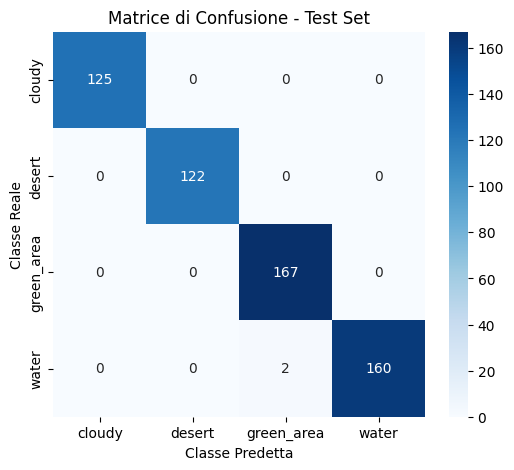

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Esecuzione della valutazione sul Test Set...")
loss, accuracy = model.evaluate(test_ds)
print(f"\nRisultati sul Test Set:")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}\n")

# Estrazione dei vettori di etichette reali e predizioni
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Recupero etichette testuali delle classi
class_names = sorted(os.listdir(data_dir))

# Stampa del report di classificazione statistico
print("--- Report di Classificazione Dettagliato ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Generazione della Matrice di Confusione grafica
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice di Confusione - Test Set')
plt.ylabel('Classe Reale')
plt.xlabel('Classe Predetta')
plt.show()

Esecuzione inferenza sul file locale: /Senza titolo.png


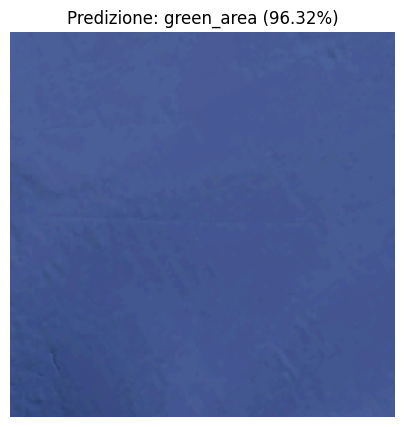


Distribuzione delle probabilità per tutte le classi:
 - cloudy      : 0.00%
 - desert      : 0.00%
 - green_area  : 96.32%
 - water       : 3.68%


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import os

# --- CONFIGURAZIONE PERCORSO IMMAGINE ---
# Sostituisci questo percorso con il nome del file che trascini nella cartella di Colab
# Es: 'mio_test.jpg' oppure puoi testarlo su una foto del dataset come fatto qui sotto:
IMAGE_PATH = "/Senza titolo.png"
# ----------------------------------------

if not os.path.exists(IMAGE_PATH):
    print(f"Errore: Il file indicato in '{IMAGE_PATH}' non esiste nello spazio del notebook. Verifica il percorso.")
else:
    print(f"Esecuzione inferenza sul file locale: {IMAGE_PATH}")

    # 1. Caricamento e ridimensionamento automatico
    img_target = load_img(IMAGE_PATH, target_size=(224, 224))

    # 2. Conversione in array e creazione del batch (1, 224, 224, 3)
    x = img_to_array(img_target)
    x = np.expand_dims(x, axis=0)

    # 3. Preprocessing identico alla fase di test
    x = tf.keras.applications.resnet50.preprocess_input(x)

    # 4. Predizione del modello
    predictions = model.predict(x, verbose=0)[0]
    predicted_class_idx = np.argmax(predictions)
    predicted_class_name = class_names[predicted_class_idx]
    confidence = predictions[predicted_class_idx] * 100

    # 5. Output grafico
    plt.figure(figsize=(5, 5))
    plt.imshow(img_target)
    plt.title(f"Predizione: {predicted_class_name} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    # Tabella riassuntiva di tutte le probabilità
    print("\nDistribuzione delle probabilità per tutte le classi:")
    for idx, name in enumerate(class_names):
        print(f" - {name.ljust(12)}: {predictions[idx]*100:.2f}%")